# Temporal Aggregation

<div class="page-subtitle">
Extracting Climate Signals and Anomalies
</div>

---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HendrikWulf/sds210-jb/blob/main/book/12_L10_time-series/07_temporal_aggregation.ipynb)

---

```{admonition} Big idea
:class: tip

Time series analysis often begins by reducing noisy observations into meaningful summaries. By reorganizing the time dimension, we can extract seasonal structure, define baseline conditions, and reveal departures from those conditions.
```

Demonstrating how to effectively collapse, reorganize, and smooth the time dimension in Python is the core pedagogical goal of this chapter. You will learn the critical differences between resampling and grouping, and master the split, apply, combine workflow to produce interpretable environmental statistics.

**Applied Scenario**
We will analyze the NOAA Extended Reconstructed Sea Surface Temperature (ERSST v5) dataset, a widely used and trusted gridded compilation of historical data going back to 1854. Our goal is to strip away the overwhelming seasonal cycle to reveal long term climate warming trends.

In [3]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc

# Load the historical sea surface temperature dataset
ds = xr.tutorial.open_dataset("ersstv5")

---

## 1. Basic Temporal Reductions

We begin by treating time as a fully reducible dimension, exactly like latitude or longitude. Reductions are functions that reduce the dimensionality of our dataset. Rather than dealing with complex loops across hundreds of temporal slices, you can perform reductions across the entire timeline simultaneously by using dimension names.

### Collapsing time

You can collapse the entire time dimension into a single 2D spatial map using standard reduction methods like `.mean(dim="time")` or `.max(dim="time")`.

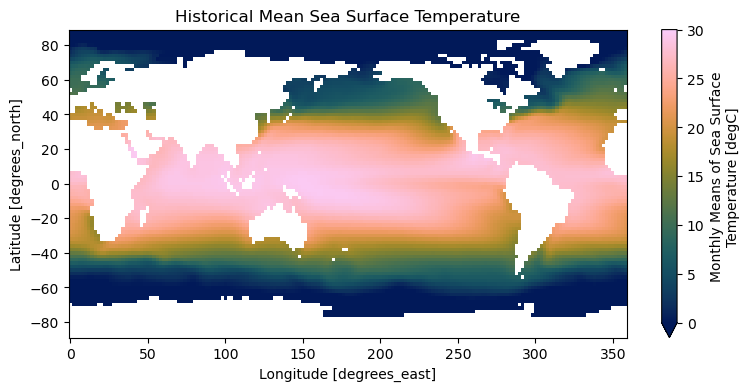

In [4]:
# Calculate the historical mean temperature for every pixel
mean_sst = ds.sst.mean(dim="time")

mean_sst.plot(cmap=cmc.batlow, figsize=(9, 4), vmin=0, vmax=30)
plt.title("Historical Mean Sea Surface Temperature")
plt.show()

<div class="figure-caption-like">
A spatial map showing the historical mean sea surface temperature. Reducing the time dimension collapses the dataset into a single 2D summary of the ocean's average state.
</div>

### Reducing multiple dimensions

You are not limited to reducing one dimension at a time. You can reduce over multiple dimensions by passing a list of dimension names. For example, to visualize the North to South temperature gradient, we can average over both time and longitude.

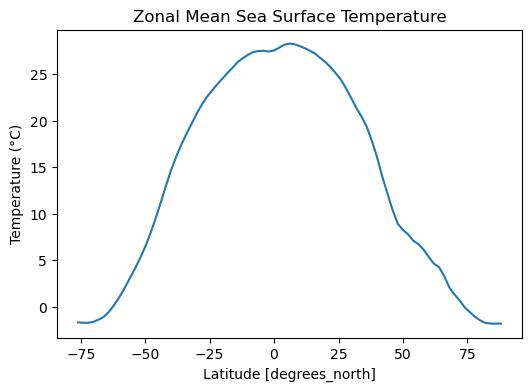

In [5]:
# Collapse time and longitude to see the average temperature by latitude
zonal_mean = ds.sst.mean(dim=["time", "lon"])

zonal_mean.plot(figsize=(6, 4))
plt.title("Zonal Mean Sea Surface Temperature")
plt.ylabel("Temperature (°C)")
plt.show()

<div class="figure-caption-like">
A 1D profile showing the zonal mean sea surface temperature. By reducing over both time and longitude, the clear temperature gradient from the warm equator to the freezing poles is revealed. Do you know which steam causes the temperature deviation from the bell-shaped curve at high northern latitudes?
</div>

### Reducing all dimensions

Furthermore, if no dimension is specified, `xarray` reduces across all dimensions, yielding a single global scalar value.

In [6]:
# Yields a single float representing the global average over all time and space
ds.sst.mean()

<xarray.DataArray 'sst' ()> Size: 4B
array(13.810618, dtype=float32)
Attributes:
    long_name:     Monthly Means of Sea Surface Temperature
    units:         degC
    var_desc:      Sea Surface Temperature
    level_desc:    Surface
    statistic:     Mean
    dataset:       NOAA Extended Reconstructed SST V5
    parent_stat:   Individual Values
    actual_range:  [-1.8     42.32636]
    valid_range:   [-1.8 45. ]

```{admonition} Reduction is general
:class: note

A reduction answers the question: *along which dimension do I want to collapse the data?* If you choose `dim="time"`, you keep the spatial pattern and summarize change through time. If you choose no dimension at all, you collapse the entire cube into one number. Time is not a special case; it is a dimension that can be summarized like any other.
```

---

## 2. Resampling: Changing Time Frequency

Environmental observations often come in one temporal frequency, but your analysis needs another. Often, you will receive data at a frequency that is too granular for your analysis. Resampling means changing the time frequency of data, usually reducing to a coarser frequency. For example, converting daily precipitation into monthly totals, or monthly temperatures into yearly averages.

This operation can be thought of as a groupby operation where each group is a chronological block of time. Resampling only works with proper datetime64 coordinate labels. 

### Monthly to yearly

The ERSST dataset is monthly. We can aggregate it into annual means using the `.resample()` method with specific frequency strings like `time="YE"` for Year End.

To make the effect of resampling visible, let us first reduce the spatial dimensions and then plot the resulting global time series.

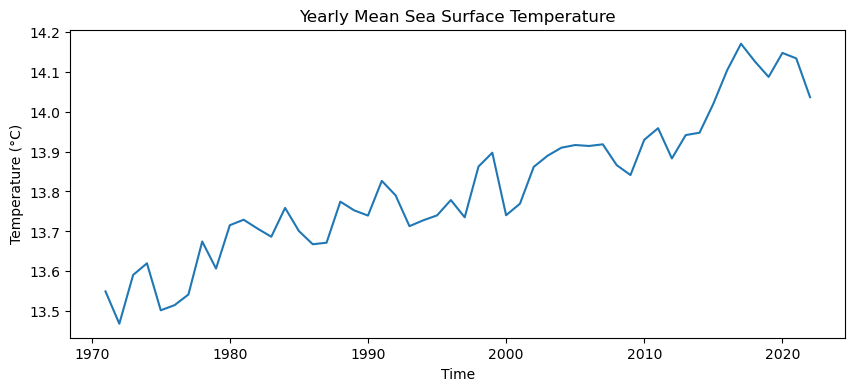

In [7]:
# 1. Resample to yearly means
sst_yearly = ds.sst.resample(time="YE").mean()

# 2. Reduce the spatial dimensions to get a global average
sst_yearly_global = sst_yearly.mean(dim=["lat", "lon"])

# 3. Plot the result
sst_yearly_global.plot(figsize=(10, 4))
plt.title("Yearly Mean Sea Surface Temperature")
plt.ylabel("Temperature (°C)")
plt.show()

<div class="figure-caption-like">
A 1D time series showing the global yearly mean sea surface temperature. Notice that the output still has a proper datetime coordinate, but the time axis now represents discrete yearly observations instead of monthly ones.
</div>

### Coarser intervals

You can also aggregate into longer blocks, for example using `time="5YE"` for 5 year intervals.

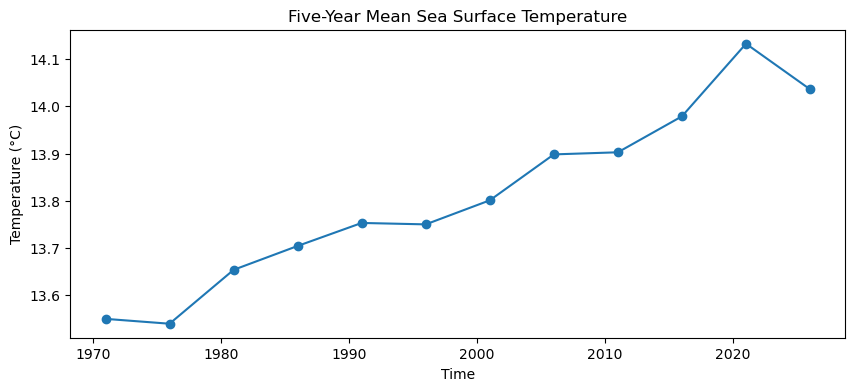

In [8]:
# Resample to 5-year means and collapse spatially
sst_5year = ds.sst.resample(time="5YE").mean()
sst_5year_global = sst_5year.mean(dim=["lat", "lon"])

sst_5year_global.plot(marker="o", figsize=(10, 4))
plt.title("Five-Year Mean Sea Surface Temperature")
plt.ylabel("Temperature (°C)")
plt.show()

<div class="figure-caption-like">
A 1D time series showing global sea surface temperature aggregated into 5 year blocks. The `marker="o"` argument highlights the exact timestamp representing the end of each 5 year period.
</div>

### The role of the aggregation statistic

The resampling method you append to the end of the operation determines the physical meaning of the result:

* Use `.mean()` for average conditions (like temperature).
* Use `.sum()` for cumulative totals (like precipitation).
* Use `.max()` for extreme conditions (like peak flood levels).

That choice is scientific, not merely technical.

```{admonition} Resampling changes frequency
:class: important

Use `.resample()` when you want to reorganize observations into consecutive chronological blocks such as months, years, or decades. The resulting time coordinate remains a proper time axis that can be plotted natively.
```

---

## 3. Grouping: Exploring Cyclical Patterns

Unlike resampling which changes the temporal frequency, **grouping** does something different. It reorganizes the data into calendar categories that already exist inside the time coordinate. For instance, gathering all the Januaries or all the summers together. 

This enables you to ask questions such as: What is the typical January temperature? Or how do the four seasons compare?

### The datetime accessor

To do this, we can use the DatetimeAccessor (`.dt`) to easily extract specific components of dates and times, such as month or season.

In [9]:
# Extract the month (1-12) or the season (DJF, MAM, JJA, SON)
print(ds.time.dt.month.values[:12])
print(ds.time.dt.season.values[:12])

[ 1  2  3  4  5  6  7  8  9 10 11 12]
['DJF' 'DJF' 'MAM' 'MAM' 'MAM' 'JJA' 'JJA' 'JJA' 'SON' 'SON' 'SON' 'DJF']


### Grouping by month

We can demonstrate the split step using `.groupby("time.month")`. To complete the workflow, we immediately chain the `.mean()` method to apply the calculation and combine the results into a new dataset.

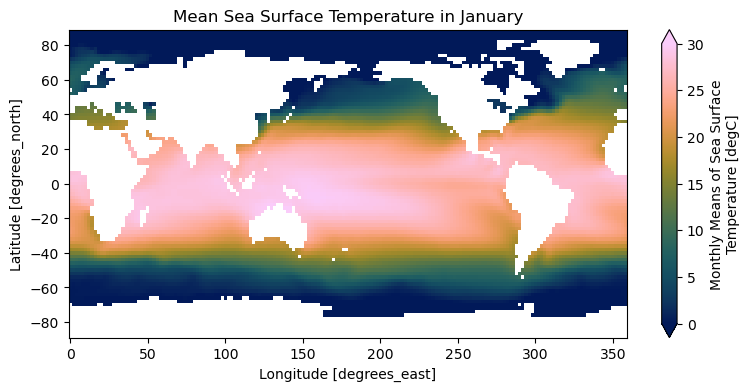

In [10]:
# Split the data into 12 monthly groups, apply the mean, and combine
sst_by_month = ds.sst.groupby("time.month").mean()

# Plot the average January temperature (index 0)
sst_by_month.isel(month=0).plot(cmap="cmc.batlow", vmin=0, vmax=30, figsize=(9, 4))
plt.title("Mean Sea Surface Temperature in January")
plt.show()

<div class="figure-caption-like">
A spatial map of the January climatology. The time axis has been replaced by a "month" coordinate containing integer labels from 1 to 12.
</div>

### Grouping by season

Grouping is the natural entry point for climatological thinking. We can easily group by season and use `xarray`'s built-in faceting to plot all four seasons side by side.

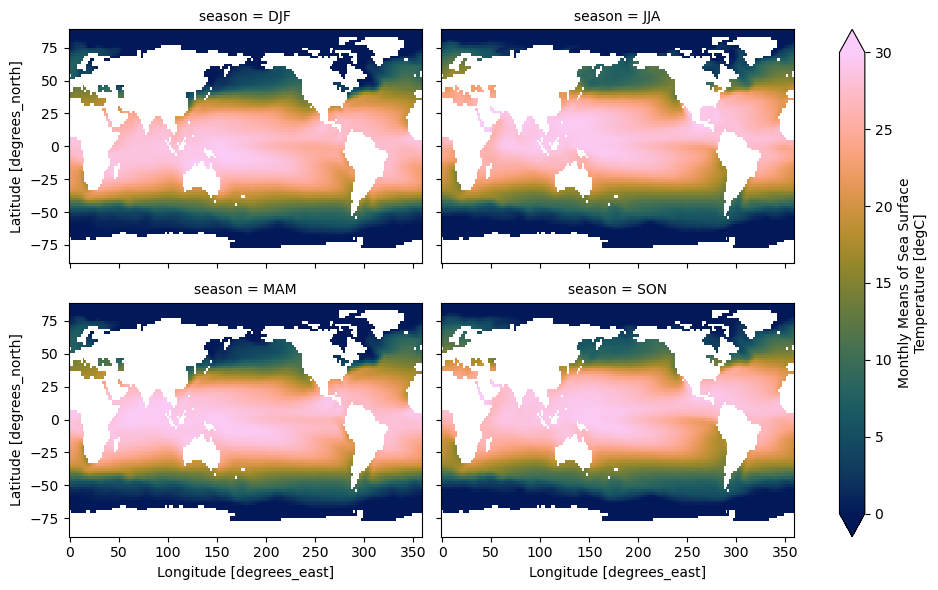

In [11]:
# Group by the four meteorological seasons
sst_by_season = ds.sst.groupby("time.season").mean()

sst_by_season.plot(
    col="season", col_wrap=2, cmap="cmc.batlow", vmin=0, vmax=30, figsize=(10, 6)
)
plt.show()

<div class="figure-caption-like">
A faceted plot showing the average sea surface temperatures for Winter (DJF), Spring (MAM), Summer (JJA), and Autumn (SON). 
</div>

### Grouping versus Resampling

This distinction is essential to understand before moving forward:

* `ds.resample(time="YE")` creates chronological bins and preserves a continuous datetime format.
* `ds.groupby("time.month")` creates category labels such as `1, 2, ..., 12`.
* `ds.groupby("time.season")` creates category strings such as `DJF`, `MAM`, `JJA`, `SON`.

```{admonition} Split, apply, combine
:class: note

Grouping follows the classic data science workflow: 
1. **Split** the data into categories (e.g., all the Januaries).
2. **Apply** a function to each group (e.g., calculate the mean).
3. **Combine** the results into one new object.
```

---

## 4. Climatologies and Anomalies

A useful application of the split, apply, combine workflow is generating climate anomalies. We often want to remove the overwhelming seasonal cycle (called the "climatology") in order to better see long term variations in temperature.

### Defining what is normal

A **climatology** is a baseline average, usually defined over a long reference period. It answers the question: *What is typical for this month or season?* Let us define a baseline period from 1971 to 2000 and calculate the monthly climatology using `gb.mean()`.

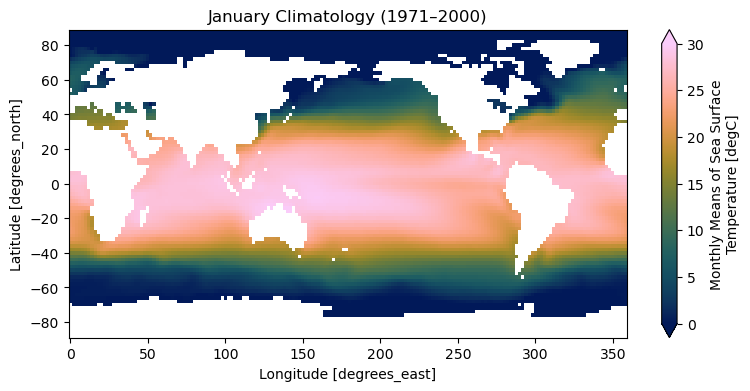

In [12]:
# 1. Isolate the baseline period
baseline = ds.sst.sel(time=slice("1971", "2000"))

# 2. Group by month and calculate the mean
monthly_climatology = baseline.groupby("time.month").mean()

# 3. Inspect the baseline for January
monthly_climatology.sel(month=1).plot(
    cmap="cmc.batlow", vmin=0, vmax=30, figsize=(9, 4)
)
plt.title("January Climatology (1971–2000)")
plt.show()

<div class="figure-caption-like">
A spatial map of the January climatology. This object now defines the expected mean sea surface temperature for every January based on our 30 year reference period.
</div>

```{admonition} Climatology is a baseline
:class: important

A climatology is not simply a continuous mean over time. It is a structured baseline that preserves seasonal differences. January observations will only be compared to the January baseline, July to July, and so on.
```

### Departures from the baseline

Once you have a climatology, you can calculate **anomalies**. An anomaly is the residual difference between the observed value and the expected value for that calendar month. 

Removing the seasonal climatology to examine the residual anomaly is a perfect example of a transformation. Xarray makes these transformations easy by supporting *groupby arithmetic*, allowing us to subtract the grouped mean directly from the original grouped object.

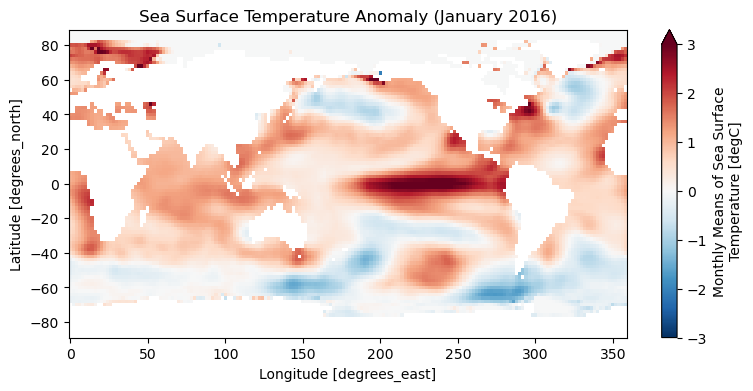

In [13]:
# Subtract the baseline climatology from the original observations
sst_anom = ds.sst.groupby("time.month") - monthly_climatology

# Inspect a single anomaly map for a recent month
anom_example = sst_anom.sel(time="2016-01-01", method="nearest")

anom_example.plot(cmap="RdBu_r", vmin=-3, vmax=3, figsize=(9, 4))
plt.title("Sea Surface Temperature Anomaly (January 2016)")
plt.show()

<div class="figure-caption-like">
An anomaly map for January 2016. The seasonal cycle is entirely removed. Red areas show where the ocean was unusually warm compared to the 1971–2000 baseline, while blue areas show where it was unusually cold.
</div>

If you are interested in long term change, raw monthly values can hide the warming signal behind strong annual summer and winter oscillations. Anomalies isolate exactly what is unusual relative to the baseline, making them the most critical tool in climate analysis.

---

## 5. Rolling windows and smoothing

Even after removing the seasonal cycle, anomaly time series can still be quite noisy. High frequency variability (like short-term weather patterns) can obscure the long term climate signal. 

A common solution is to apply a **rolling mean** using `xarray`'s built-in `.rolling()` method, which creates sliding windows of fixed length. 

### A 12 month rolling mean

Let us create a simple global mean anomaly series and smooth it with a 12 month rolling window. We use `center=True` to ensure the moving average is centered on the current timestamp rather than trailing it.

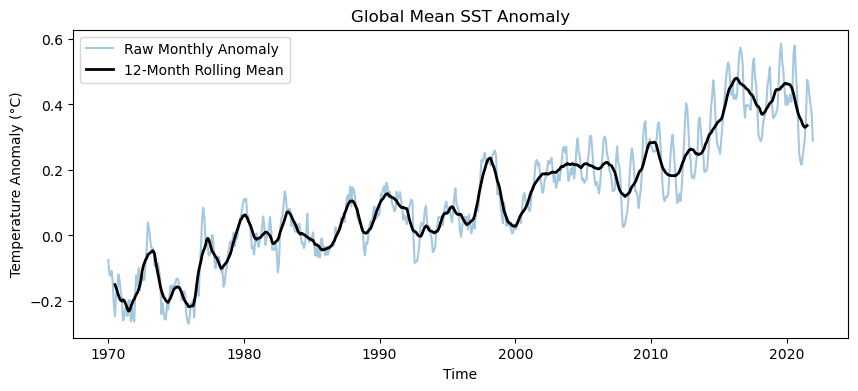

In [14]:
# 1. Create a raw global mean anomaly series
sst_anom_global = sst_anom.mean(dim=["lat", "lon"])

# 2. Smooth it using a 12-month sliding window
sst_anom_roll12 = sst_anom_global.rolling(time=12, center=True).mean()

# 3. Plot both to see the effect
fig, ax = plt.subplots(figsize=(10, 4))
sst_anom_global.plot(ax=ax, alpha=0.4, label="Raw Monthly Anomaly")
sst_anom_roll12.plot(ax=ax, color="black", linewidth=2, label="12-Month Rolling Mean")

ax.set_title("Global Mean SST Anomaly")
ax.set_ylabel("Temperature Anomaly (°C)")
ax.legend()
plt.show()

<div class="figure-caption-like">
A 1D time series of global temperature anomalies. The light blue line shows the raw monthly data, while the black line shows the smoothed 12 month rolling average, making the upward warming trend easier to see.
</div>

### Rolling versus Resampling

It is important to understand what a rolling window does differently:
* `.resample()` creates entirely new, coarser time bins (e.g., jumping from month to month).
* `.rolling()` smooths the data *without* changing the fundamental time frequency. It keeps the exact same time axis, padding the boundaries with `NaN`s if necessary.

```{admonition} A note on coarsen
:class: note

Another useful tool is `.coarsen()`, which aggregates over fixed, non-overlapping blocks. It is similar to `.rolling()`, but instead of sliding point-by-point, it jumps from block to block. It is often used to downsample high-resolution spatial datasets.
```

---

## 6. Spatial Weighting

So far, we have discussed calculating global mean anomalies using a simple spatial average over latitude and longitude. While that is easy, it is not fully correct for a regular lat lon grid. 

Because grid cells near the poles cover less physical area than cells near the equator, a simple mean overrepresents the polar regions. If every cell contributes equally, your global temperature will be skewed.

### Latitude based weights

To fix this, a standard correction is to weight the pixels by the cosine of their latitude. These weights will naturally be largest near the equator and smallest near the poles.

Xarray provides a `.weighted()` mechanism that creates a special `DataArrayWeighted` object, allowing you to apply reduction operations accurately.

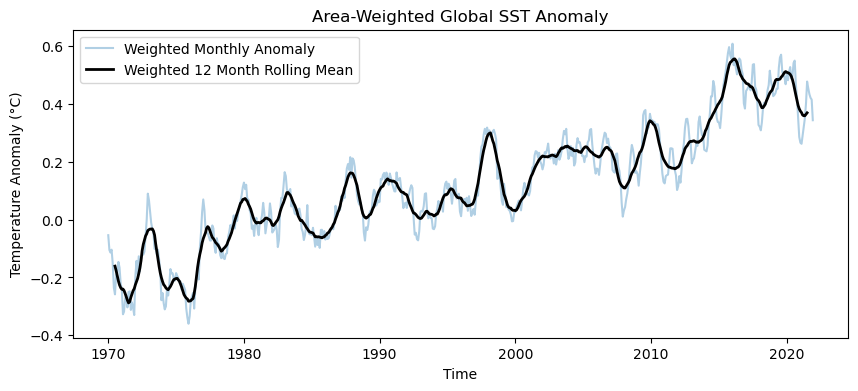

In [15]:
# 1. Create a weights array proportional to the cosine of latitude
weights = np.cos(np.deg2rad(ds.lat))

# 2. Apply the weights to our monthly anomalies and collapse spatially
sst_anom_weighted = sst_anom.weighted(weights).mean(dim=["lat", "lon"])

# 3. Apply a 12 month rolling mean to the resulting 1D time series
sst_anom_weighted_roll12 = sst_anom_weighted.rolling(time=12, center=True).mean()

# 4. Plot the results
fig, ax = plt.subplots(figsize=(10, 4))
sst_anom_weighted.plot(ax=ax, alpha=0.35, label="Weighted Monthly Anomaly")
sst_anom_weighted_roll12.plot(
    ax=ax, color="black", linewidth=2, label="Weighted 12 Month Rolling Mean"
)

ax.set_title("Area-Weighted Global SST Anomaly")
ax.set_ylabel("Temperature Anomaly (°C)")
ax.legend()
plt.show()

<div class="figure-caption-like">
An area weighted global time series of sea surface temperature anomalies. By properly accounting for the Earth's geometry, this chart provides a scientifically rigorous view of historical ocean warming.
</div>

For very small local regions, weighting may not change the results significantly. However, for large regional or global summaries, it matters immensely.

---

## 7. Visualizing Anomalies

Temporal aggregation and groupby arithmetic become much easier to interpret once you visualize the results. These plots are not different datasets; they are simply different reorganizations of the exact same data cube, each highlighting a specific aspect of the Earth's temporal behavior.

### The global seasonal cycle

To understand the baseline we established earlier, we can plot the global average of our monthly climatology. Because we are aggregating over a large geographic area (the entire globe) to create a 1D time series, we must remember to apply our spatial weights!

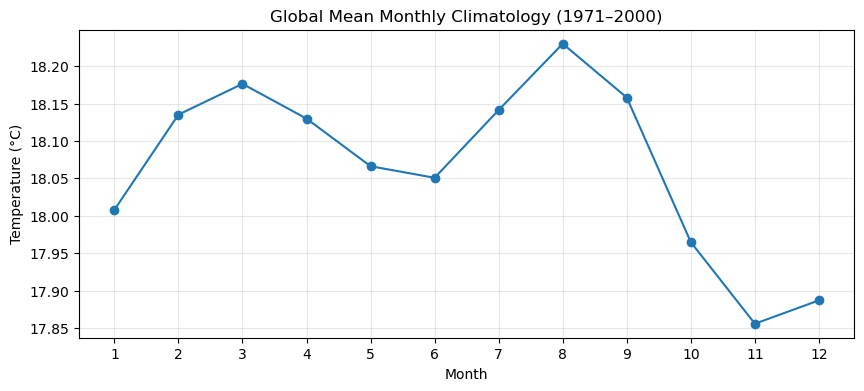

In [16]:
# 1. Apply the spatial weights to our climatology
weighted_climatology = monthly_climatology.weighted(weights)

# 2. Calculate the global mean and plot the seasonal profile
weighted_climatology.mean(dim=["lat", "lon"]).plot(marker="o", figsize=(10, 4))

plt.title("Global Mean Monthly Climatology (1971–2000)")
plt.ylabel("Temperature (°C)")
plt.xlabel("Month")
plt.xticks(range(1, 13))  # Ensure all 12 months are labeled
plt.grid(alpha=0.3)
plt.show()

<div class="figure-caption-like">
A 1D profile of the global seasonal cycle. This curve represents the "expected" baseline temperature for the Earth during each calendar month.
</div>

### Tracking anomalies over time

While 1D global means are great for overall trends, we often want to see exactly *where* extreme events are happening. To see how anomalies shift geographically across a specific year, we can use `xarray`'s built-in faceting.

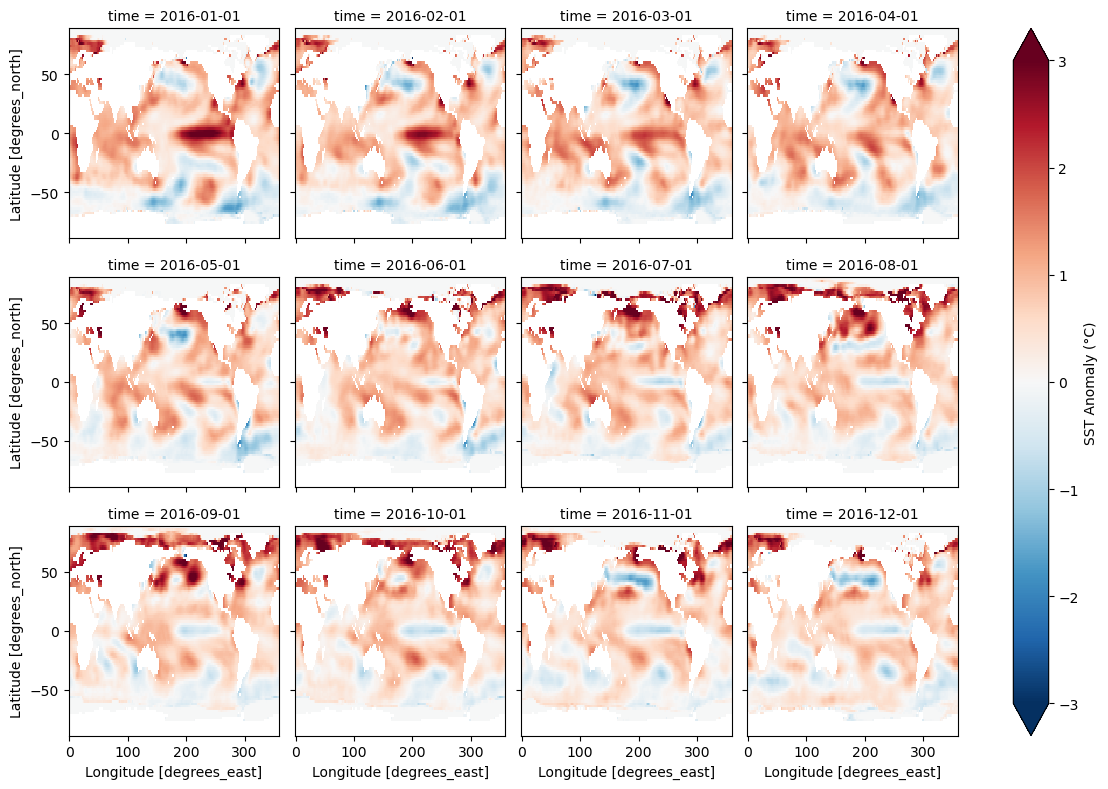

In [17]:
# Isolate the anomaly data for a single highly anomalous year
anom_2016 = sst_anom.sel(time="2016")

# Plot all 12 months in a grid
anom_2016.plot(
    col="time",
    col_wrap=4,
    cmap="RdBu_r",
    vmin=-3,
    vmax=3,
    figsize=(12, 8),
    cbar_kwargs={"label": "SST Anomaly (°C)"},
)
plt.show()

<div class="figure-caption-like">
Faceted spatial anomalies for the year 2016. Faceting is incredibly helpful here because it forces every subplot to share the exact same color scale, allowing you to track the evolution of extreme warming (red) and cooling (blue) events, such as El Niño, month by month.
</div>

---

## 8. Exercise: The Long Term Signal

Use the NOAA `ersstv5` dataset to bring all the concepts together and visualize the long term warming signal clearly.

**Your Task:**
1. **Baseline:** Calculate a monthly climatology over the baseline period 1971 to 2000.
2. **Anomalies:** Compute monthly anomalies by subtracting the climatology from the full series.
3. **Weight:** Compute cosine latitude weights.
4. **Aggregate:** Calculate an area weighted global mean anomaly time series.
5. **Smooth:** Apply a 60 month (5 year) rolling mean to smooth the anomaly time series.
6. **Plot:** Create a plot that shows both the raw weighted monthly anomaly (faded in the background) and the final smoothed time series (bolded on top).
7. **Interpret:** Write two short sentences explaining what becomes visible once the seasonal cycle has been removed.

**Starter code:**

In [18]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

ds = xr.tutorial.open_dataset("ersstv5")

# 1. Baseline climatology (1971 to 2000)
# ...

# 2. Monthly anomalies
# ...

# 3. Latitude based weights
# ...

# 4. Area weighted global mean anomaly
# ...

# 5. Five year rolling mean (60 months)
# ...

# 6. Plot
# ...

````{admonition} Sample solution
:class: dropdown

```{code-cell} python
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

ds = xr.tutorial.open_dataset("ersstv5")

# 1. Baseline climatology
baseline = ds.sst.sel(time=slice("1971", "2000"))
monthly_climatology = baseline.groupby("time.month").mean()

# 2. Monthly anomalies
sst_anom = ds.sst.groupby("time.month") - monthly_climatology

# 3. Latitude based weights
weights = np.cos(np.deg2rad(ds.lat))

# 4. Area weighted global mean anomaly
sst_anom_weighted = sst_anom.weighted(weights).mean(dim=["lat", "lon"])

# 5. Five year rolling mean (60 months)
sst_anom_smooth = sst_anom_weighted.rolling(time=60, center=True).mean()

# 6. Plot
fig, ax = plt.subplots(figsize=(10, 4))
sst_anom_weighted.plot(ax=ax, alpha=0.3, label="Monthly Anomaly")
sst_anom_smooth.plot(ax=ax, color="black", linewidth=2, label="5-Year Rolling Mean")

ax.set_title("Area Weighted Global SST Anomaly")
ax.set_ylabel("Temperature Anomaly (°C)")
ax.axhline(0, color="black", linestyle="--", alpha=0.5)
ax.legend()
plt.grid(alpha=0.3)
plt.show()
```

:::{figure} images/13_ex_warming_trend.png
:alt: A line graph showing the global sea surface temperature anomaly from 1850 to present. A noisy faded blue line shows the monthly anomaly, while a bold black line shows the smoothed 5-year rolling mean trending distinctly upward in recent decades.
:width: 700px
:align: center
:::

**Interpretation:**
> The seasonal cycle is no longer dominating the series, so the long term warming signal becomes much easier to see. The rolling mean filters out short term variability and reveals a clear, accelerating upward trajectory through time.
````

---

## 9. Summary

By manipulating the time dimension in `xarray`, we can transition from raw, noisy observations to clear climate signals.

* **Temporal Reductions:** Time is not just a list of bands; it is a fully indexable, date-aware dimension that can be collapsed and reduced exactly like latitude or longitude.
* **Resampling vs. Grouping:** This distinction is critical. Use `.resample()` to change the chronological frequency of your data (e.g., monthly to yearly). Use `.groupby()` alongside the `.dt` accessor to extract cyclical patterns (e.g., evaluating all Januaries) using the split, apply, combine workflow.
* **Climatologies and Anomalies:** A climatology establishes a reference baseline of what is "normal." Groupby arithmetic (`gb - gb.mean()`) is the standard, elegant method for subtracting this baseline to calculate climate anomalies.
* **Smoothing Trends:** Use `.rolling()` to apply sliding windows that filter out high-frequency weather noise and reveal long-term climate trends without altering the underlying time axis.
* **Spatial Weighting:** Never plot global or regional time series aggregated from a regular lat-lon grid without first applying spatial weights (like the cosine of latitude) to mathematically correct for the Earth's spherical geometry.